# Task 1 — Exploratory Data Analysis

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

rpath = os.path.abspath('..')
if rpath not in sys.path:
    sys.path.insert(0, rpath)

from src.loader import SlackDataLoader
import src.utils as utils

sns.set_theme(style='whitegrid')
DATA_PATH = os.path.join(rpath, 'data', 'anonymized')

In [6]:
loader = SlackDataLoader(DATA_PATH)
id_to_name, _ = loader.get_user_map()
df = loader.get_all_messages()

print(f'Total messages: {len(df):,}')
print(f'Channels: {df["channel"].nunique()}')
print(f'Users: {df["user"].nunique()}')
df.head()


Total messages: 18,945
Channels: 35
Users: 63


,msg_id,text,user,mentions,emojis,reactions,replies,replies_to,ts,links,link_count,reply_count,reaction_count,replies_meta,channel
0,947b1f7f-9d06-47af-8ef5-1f3b10f46d60,"hi guys,\ni thought having a group chat would ...",U03U9FWPNCE,"[U03U1HAG9TR, U03UG4Q7V42]",[],None,None,None,1661766066.863109,[],0.0,0.0,0.0,None,ab_test-group
1,535ba967-4c18-4767-952b-1d53cb21ac05,good!!,U03UD4FEDHB,[],[],None,None,None,1661766159.852649,[],0.0,0.0,0.0,None,ab_test-group
2,100a9881-9733-4524-bccc-c7f81a5ff523,thanks <@u03u9fwpnce>,U03U1HAG9TR,[U03U9FWPNCE],[],None,None,None,1661766226.215889,[],0.0,0.0,0.0,None,ab_test-group
3,02a57858-3cdf-4244-88e2-c54223d8fbbe,nice <@u03u9fwpnce>,U03UG4Q7V42,[U03U9FWPNCE],[],None,None,None,1661766241.597379,[],0.0,0.0,0.0,None,ab_test-group
4,25dc5d9d-3a19-45b3-844a-aaa3ac9080ee,i have been missing deadlines and i am trying ...,U03U9FWPNCE,[],[],None,None,None,1661766295.939119,[],0.0,0.0,0.0,None,ab_test-group


## 1. Top and bottom 10 users

Metrics: message count, reply count, mention count, and reactions received.

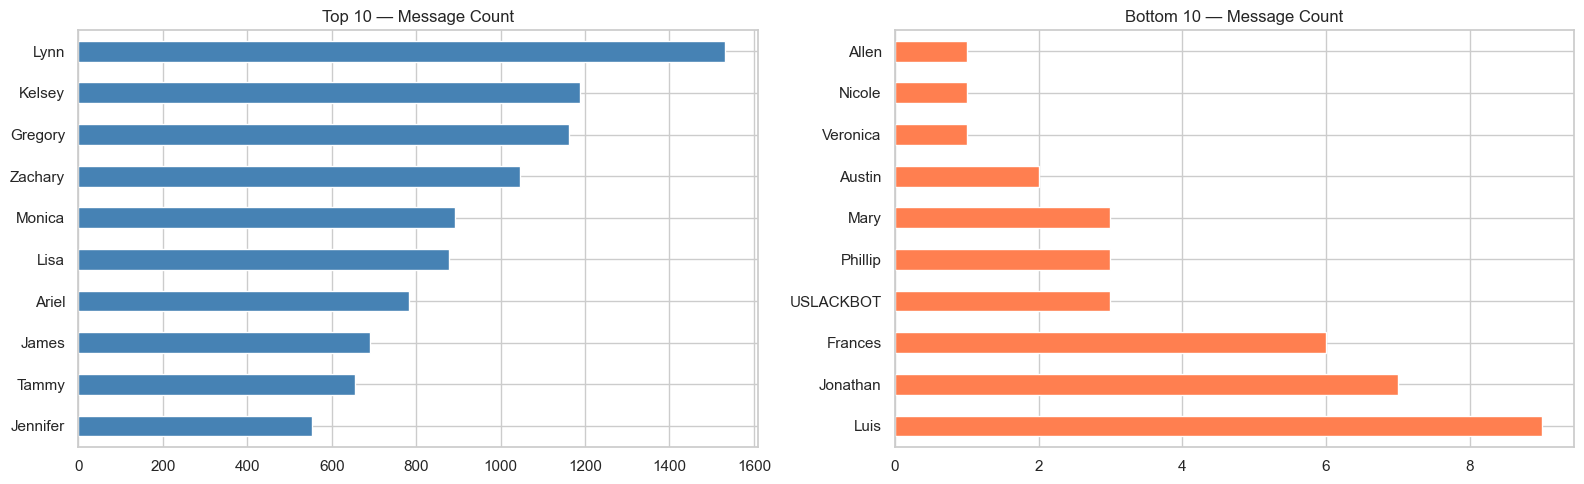

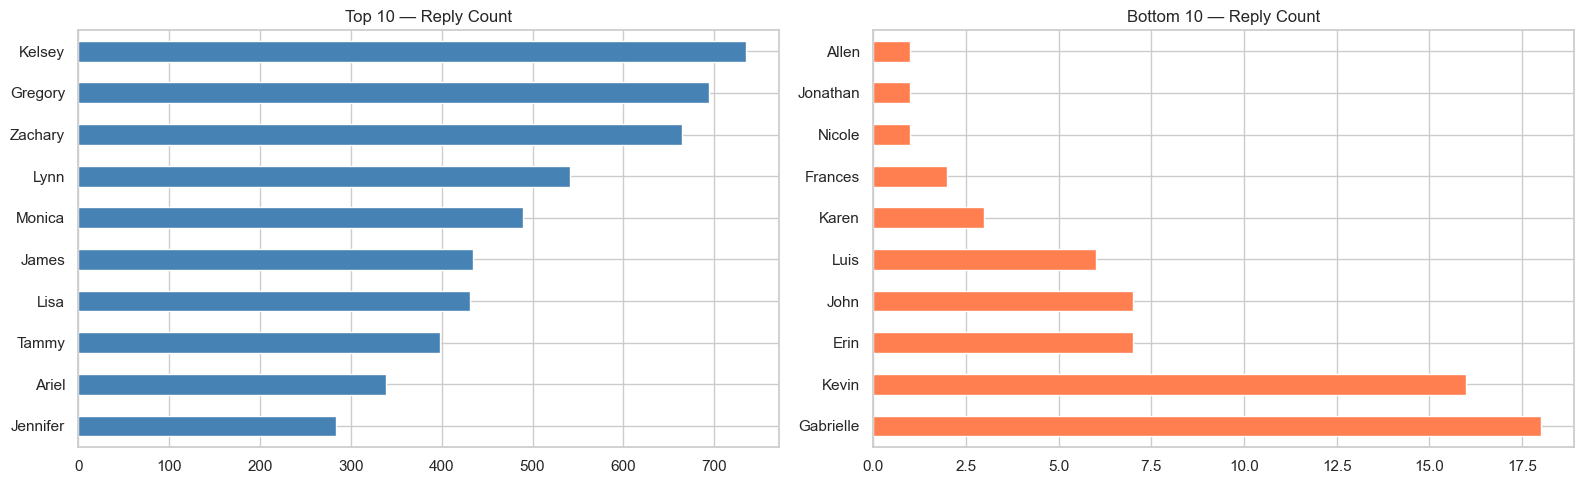

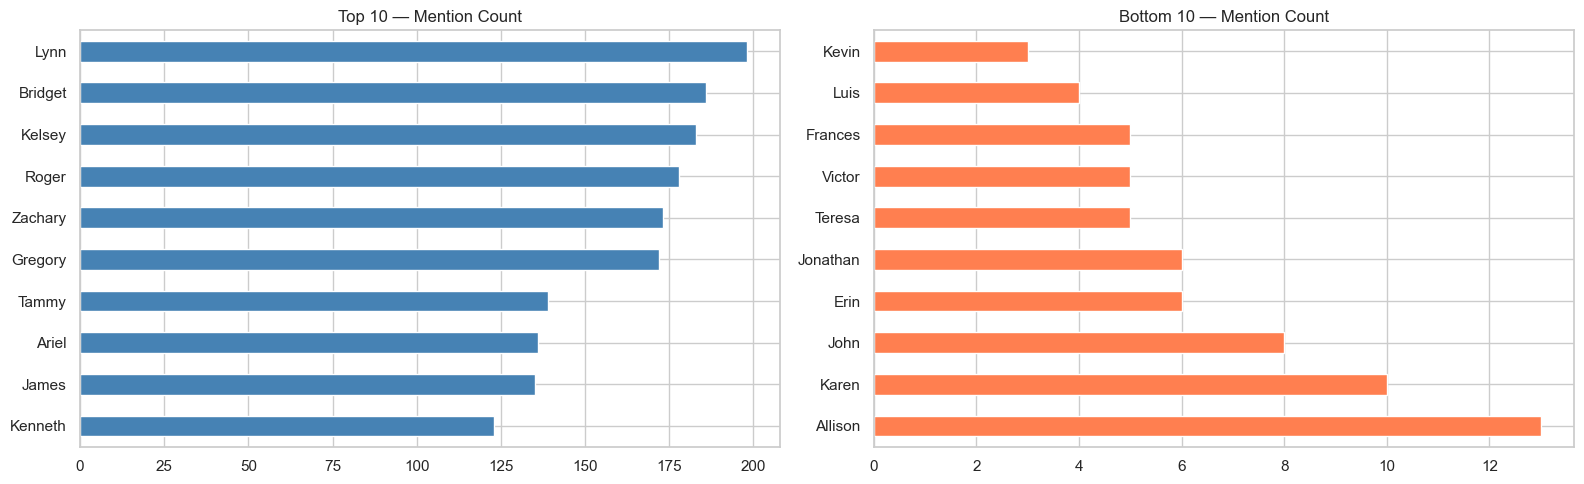

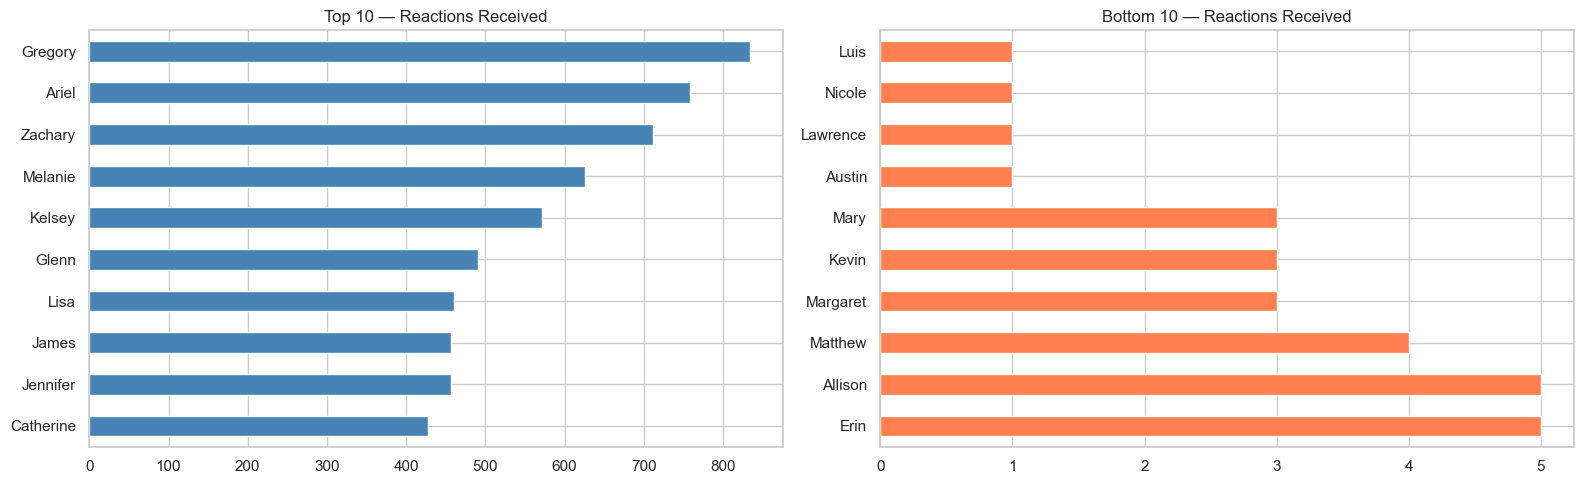

In [ ]:
def show_top_bottom(series, title, n=10):
    named = series.rename(index=id_to_name)
    top = named.sort_values(ascending=False).head(n)
    bottom = named.sort_values(ascending=True).head(n)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    top.plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title(f'Top {n} — {title}')
    axes[0].invert_yaxis()

    bottom.plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title(f'Bottom {n} — {title}')
    axes[1].invert_yaxis()
    plt.tight_layout()
    plt.show()

    return top, bottom

message_counts = df['user'].value_counts()
reply_counts = pd.Series(utils.count_replies_by_user(df))
mention_counts = pd.Series(utils.count_mentions_by_user(df))
reaction_received_counts = pd.Series(utils.count_reactions_received_by_user(df))

top_msg, bottom_msg = show_top_bottom(message_counts, 'Message Count')
top_reply, bottom_reply = show_top_bottom(reply_counts, 'Reply Count')
top_mention, bottom_mention = show_top_bottom(mention_counts, 'Mention Count')
top_reaction, bottom_reaction = show_top_bottom(reaction_received_counts, 'Reactions Received')

## 2. Top 10 messages by replies, reactions, and mentions

In [ ]:
df['mention_count'] = df['mentions'].apply(lambda m: len(m) if isinstance(m, list) else 0)

cols = ['channel', 'user', 'text', 'reply_count', 'reaction_count', 'mention_count']

print('Top 10 messages by replies')
display(df.nlargest(10, 'reply_count')[cols])

print('Top 10 messages by reactions')
display(df.nlargest(10, 'reaction_count')[cols])

print('Top 10 messages by mentions')
display(df.nlargest(10, 'mention_count')[cols])

Top 10 messages by replies


,channel,user,text,reply_count,reaction_count,mention_count
17070,kafka_de,U03UUP56MDF,<!here> i'm getting this error when i try to p...,168.0,0.0,0
10600,all-community-building,U03UJKJGRAQ,<@u03v1am5tfa> how many crushes you have?,75.0,0.0,1
4846,all-community-building,U03U1FQKEMV,first impression: people think i am older than...,63.0,4.0,0
15858,all-week7,U03UD68RQH3,1. how do i find my jupyter notebook file in m...,61.0,0.0,2
9209,all-community-building,U03UJKJGRAQ,how many here follow football so much? i think...,57.0,5.0,0
10969,all-ideas,U03UHB8CXDY,"if meta stock's decline continues like this,fa...",57.0,0.0,0
17538,random,U03UFV7TUTV,ethiopian new year loading ....,54.0,0.0,0
17940,random,U03UJGP0C68,how is this possible :grin: see the reply time,48.0,0.0,0
1596,all-broadcast,U03V1AM5TFA,hello\n1. <@u03uvhcv6kb>\n2. <@u03ug5vfn03>\n3...,45.0,0.0,0
13347,all-week10,U03V785NLSU,<@u03uur571a5> solutions to funding account an...,44.0,0.0,1


Top 10 messages by reactions


,channel,user,text,reply_count,reaction_count,mention_count
2411,all-career-exercises,U03TT5KEYCF,<!channel>\nthere will be no careers exercise ...,0.0,36.0,0
16140,all-week9,U03TEPYRM2P,"good morning winners, welcome to week 9 of wee...",0.0,26.0,0
9129,all-community-building,U03V1AM5TFA,*news news* *<!here>*........:drum_with_drumst...,0.0,25.0,0
16253,all-week9,U03U93GNNVB,<@u03ujgp0c68> <@u03uur571a5> <@u03v785nlsu> p...,0.0,24.0,3
1508,all-broadcast,U03TEPYRM2P,*update on week 9 activities*\n<!channel> this...,0.0,21.0,0
5957,all-community-building,U03V1AM5TFA,*guys <!here>.... make sure to come back from ...,6.0,20.0,0
9417,all-community-building,U03V1AM5TFA,*hot seat announcement! <!here>*\n_*good morni...,0.0,20.0,1
1198,all-broadcast,U03U93GNNVB,little known fact - all Joanne academy technic...,0.0,19.0,0
1715,all-broadcast,U03V1AM5TFA,i will be visiting your social media to commen...,0.0,17.0,0
5286,all-community-building,U03UG0SFHGT,my reactions when am not finished the task bef...,1.0,17.0,0


Top 10 messages by mentions


,channel,user,text,reply_count,reaction_count,mention_count
10152,all-community-building,U03V6HMRPGQ,"i am grateful for <@u03u93gnnvb>, <@u03uun8m4r...",1.0,13.0,25
10128,all-community-building,U03UG0YHAUT,knowing <!here> is just great one way or the o...,0.0,9.0,20
10104,all-community-building,U03UG32J3PC,i am grateful to <@u03u9db7reg> for answering ...,6.0,10.0,17
18086,random,U03UG32J3PC,<@u03uvhcv6kb> <@u03uup56mdf> <@u03ujgrn5e0> <...,0.0,0.0,13
3362,all-community-building,U03U93GNNVB,thanks to the team <@u03up7v9q57> <@u03ukl27b0...,0.0,11.0,12
10131,all-community-building,U03UG4Q7V42,i want to say thanks to <@u03v1am5tfa> for mak...,2.0,12.0,12
10119,all-community-building,U03U1HAG9TR,i am grateful to <@u03u9db7reg> for her assist...,0.0,8.0,11
10122,all-community-building,U03UJGP0C68,i would like to thank all members of the Joan...,2.0,10.0,11
6372,all-community-building,U03V1AM5TFA,news news *<!here>*........:drum_with_drumstic...,0.0,13.0,9
1640,all-broadcast,U03UG32J3PC,<@u03uvhcv6kb> <@u03v61vgqg0> <@u03ujgrn5e0> <...,0.0,1.0,8


## 3 & 4. Channel activity and engagement

**Question A:** Which channel has the highest activity?

**Question B:** On a scatter plot (x = message count, y = replies + reactions), which channel sits in the **top-right corner**?

- **Activity** is measured by **message count** (how many messages were sent in the channel).
- **Top-right corner** means the channel with the **most messages** and the **most replies + reactions** combined — i.e. high volume *and* high engagement.

A — Highest activity channel:
  Channel: #all-community-building
  Messages: 8,238
  Replies (sum): 3,892
  Reactions (sum): 7,016


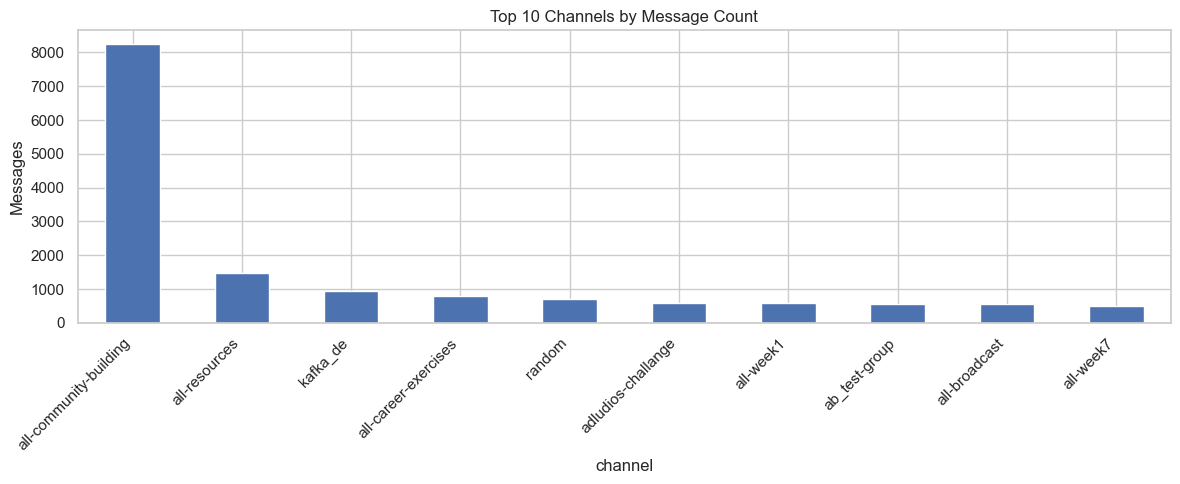

In [10]:
channel_activity = utils.get_channel_activity(df)

# --- Question A: highest activity (by message count) ---
most_active_channel = channel_activity.index[0]
most_active = channel_activity.iloc[0]

print('A — Highest activity channel:')
print(f'  Channel: #{most_active_channel}')
print(f'  Messages: {int(most_active["message_count"]):,}')
print(f'  Replies (sum): {int(most_active["reply_total"]):,}')
print(f'  Reactions (sum): {int(most_active["reaction_total"]):,}')

channel_activity.head(10).plot(kind='bar', y='message_count', figsize=(12, 5), legend=False)
plt.title('Top 10 Channels by Message Count')
plt.ylabel('Messages')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Question B — Scatter plot (messages vs replies + reactions)

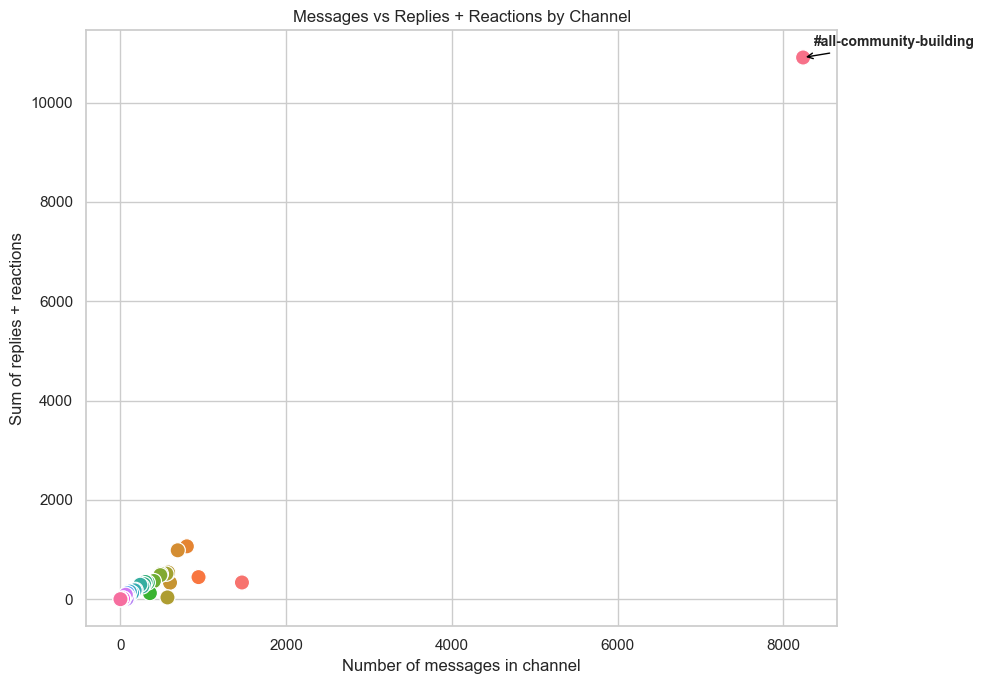

Question B — Top-right corner channel:
  Channel: #all-community-building
  Messages (x): 8,238
  Replies + reactions (y): 10,908


In [11]:
plot_data = channel_activity.reset_index()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_data,
    x='message_count',
    y='engagement_total',
    hue='channel',
    s=120,
    legend=False,
)

# Top-right = highest message count AND highest replies + reactions
top_right_channel = channel_activity.sort_values(
    ['message_count', 'engagement_total'], ascending=False
).index[0]
top_right = channel_activity.loc[top_right_channel]

plt.annotate(
    f'#{top_right_channel}',
    (top_right['message_count'], top_right['engagement_total']),
    textcoords='offset points',
    xytext=(8, 8),
    fontsize=10,
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black'),
)
plt.title('Messages vs Replies + Reactions by Channel')
plt.xlabel('Number of messages in channel')
plt.ylabel('Sum of replies + reactions')
plt.tight_layout()
plt.show()

print('Question B — Top-right corner channel:')
print(f'  Channel: #{top_right_channel}')
print(f'  Messages (x): {int(top_right["message_count"]):,}')
print(f'  Replies + reactions (y): {int(top_right["engagement_total"]):,}')

### Answer summary

| Question | Metric | Answer |
|----------|--------|--------|
| Highest activity | Most messages sent | `#all-community-building` (8,238 messages) |
| Top-right corner | Most messages **and** most replies + reactions | `#all-community-building` (8,238 messages, 10,908 replies + reactions) |

For this dataset, both answers are the same channel because `all-community-building` dominates every other channel on both axes — it is far above the rest in message volume and in engagement.

## 5. Fraction of messages replied within 5 minutes

Fraction replied within 5 minutes: 66.85%


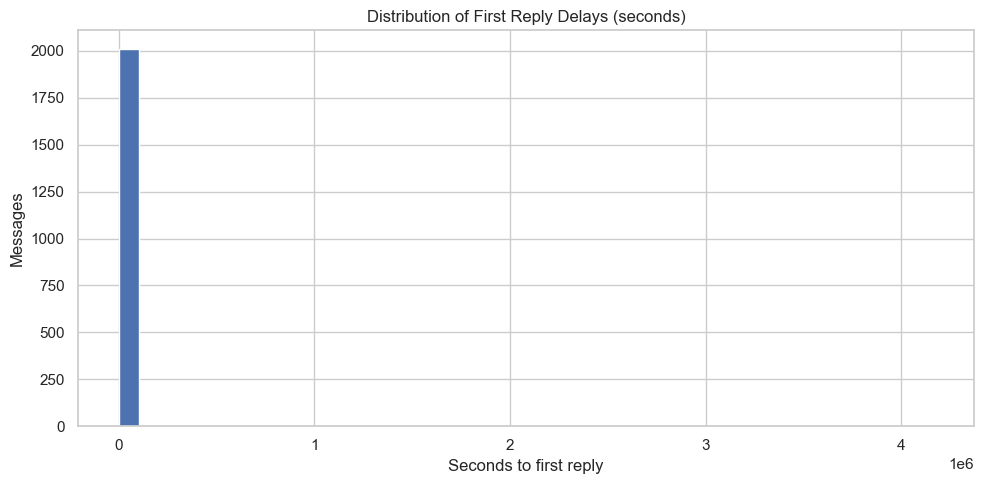

In [ ]:
timed_df = utils.add_reply_timing_columns(df)
fraction_5min = utils.fraction_replied_within_minutes(df, minutes=5)

print(f'Fraction replied within 5 minutes: {fraction_5min:.2%}')

timed_df['first_reply_delay_sec'].dropna().hist(bins=40, figsize=(10, 5))
plt.title('Distribution of First Reply Delays (seconds)')
plt.xlabel('Seconds to first reply')
plt.ylabel('Messages')
plt.tight_layout()
plt.show()

## 6. Reply delay vs time of day

Scatter plot: x = time to first reply, y = hour of day (24h), color = channel.

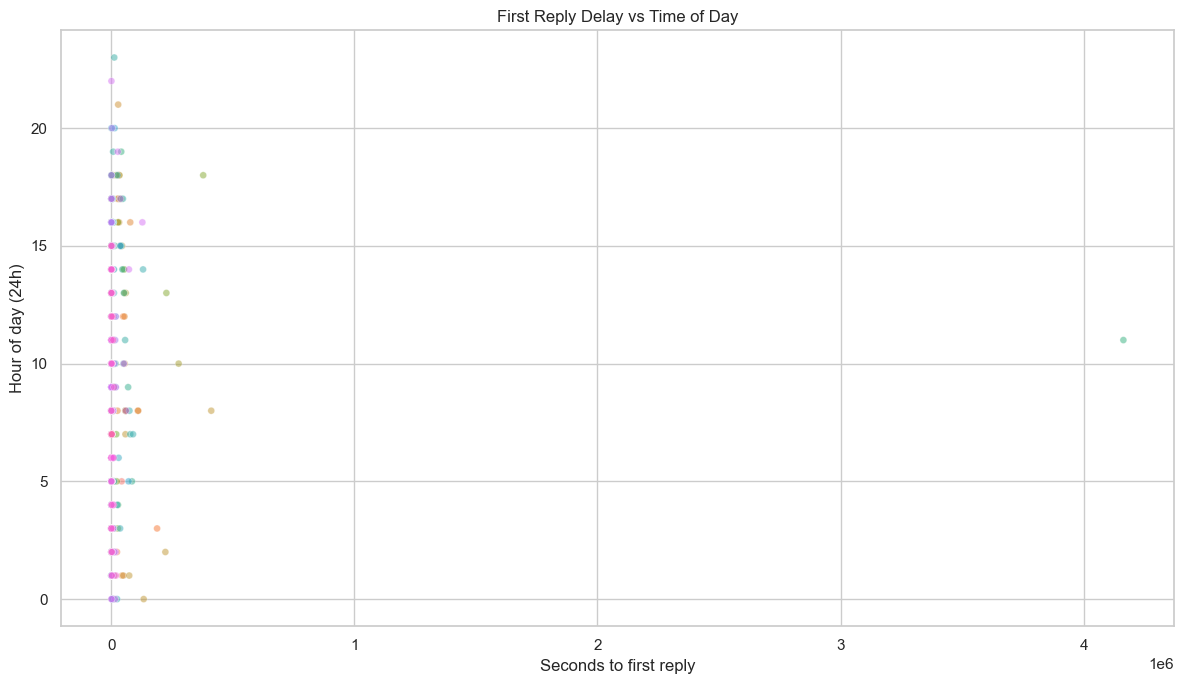

In [13]:
plot_df = timed_df.dropna(subset=['first_reply_delay_sec', 'hour_of_day'])

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_df,
    x='first_reply_delay_sec',
    y='hour_of_day',
    hue='channel',
    alpha=0.5,
    s=25,
    legend=False,
)
plt.title('First Reply Delay vs Time of Day')
plt.xlabel('Seconds to first reply')
plt.ylabel('Hour of day (24h)')
plt.tight_layout()
plt.show()

## Key takeaways

Fill in your observations after running the notebook:

- Who are the most active contributors overall?
- Which channels drive the most discussion?
- Are replies typically fast, or delayed?
- Do certain hours of the day show faster response times?